# Improvement : Combining multiple Methods with less classes to predict

In this part we are doing combine several methods as in part 4.1 but with less classes to predict (from 5 to 3) and we are trying to better the distribution of data, to better the performances of our models. 


### Import data

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report


# Load the cleaned dataset
california_data_cleaned = pd.read_csv('california_data_cleaned.csv')


In [2]:

# Define bins and labels in strictly increasing order
bins = [0,  150000, 250000, california_data_cleaned['median_house_value'].max()]
labels = ['Low',  'Medium',  'High']

# Create a new categorical column
california_data_cleaned['House_Value_Category'] = pd.cut(
    california_data_cleaned['median_house_value'], bins=bins, labels=labels
)

# Verify the distribution of the categories
print(california_data_cleaned['House_Value_Category'].value_counts())

House_Value_Category
Low       7462
Medium    7023
High      5271
Name: count, dtype: int64


The distribution of the data seems better

In [3]:

# Define features and target
X = california_data_cleaned.drop(columns=['median_house_value', 'House_Value_Category'])
y = california_data_cleaned['House_Value_Category']


In [4]:



X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [5]:
# Standardize the features



scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# List of models to evaluate




models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True, random_state=42),  # SVM with probabilities for later soft voting
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB()
}

# Initialize an empty list to store the results
results = []

In [7]:


# Best hyperparameters for Random Forest found in part 3
best_rf_params = {
    'n_estimators': 200,
    'max_depth': None,
    'max_features': 'sqrt',
    'min_samples_split': 5,
    'min_samples_leaf': 1,
}

# Best hyperparameters for SVM found in part 3
best_svm_params = {
    'C': 100,         
    'gamma': 0.1,   
    'kernel': 'rbf',
}
best_lr_params = {
    'solver': 'lbfgs',  # Optimization algorithm
    'max_iter': 1000,   # Maximum number of iterations
    'random_state': 42
}

# List of models to evaluate
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(**best_rf_params, random_state=42),
    "SVM": SVC(**best_svm_params, probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Logistic Regression" : LogisticRegression(**best_lr_params),

}

In [8]:


# Initialize an empty list to store the results
results = []

# Train and evaluate each model
for model_name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    
    # Compute performance metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted") 
    recall = recall_score(y_test, y_pred, average="weighted")      
    f1 = f1_score(y_test, y_pred, average="weighted")               
    
    # Append the results to the list
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

# Create a DataFrame to display the results
results_df = pd.DataFrame(results)

print(results_df)


                 Model  Accuracy  Precision    Recall  F1-Score
0        Decision Tree  0.753036   0.752750  0.753036  0.752884
1        Random Forest  0.816802   0.817996  0.816802  0.816870
2                  SVM  0.788209   0.788629  0.788209  0.787905
3                  KNN  0.741650   0.739269  0.741650  0.739673
4          Naive Bayes  0.652075   0.664792  0.652075  0.655505
5  Logistic Regression  0.733300   0.733327  0.733300  0.733088


Naive bayes has overall very bad accuracy and precision , we decide to remove it for the voting. 

### Hard voting : 

In [9]:


# Best hyperparameters for Random Forest
best_rf_params = {
    'n_estimators': 200,
    'max_depth': None,
    'max_features': 'sqrt',
    'min_samples_split': 5,
    'min_samples_leaf': 1,
}

# Best hyperparameters for SVM
best_svm_params = {
    'C': 10,
    'gamma': 0.1,
    'kernel': 'rbf',
}



# Define the base classifiers with best parameters
voting_estimators = [
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Random Forest', RandomForestClassifier(**best_rf_params, random_state=42)),
    ('SVM', SVC(**best_svm_params, probability=True, random_state=42)),  # Use probability=True for soft voting
    ('KNN', KNeighborsClassifier(n_neighbors=5)),
    ('Logistic Regression', LogisticRegression(**best_lr_params))
]

# Initialize the VotingClassifier with hard voting
voting_clf_hard = VotingClassifier(estimators=voting_estimators, voting='hard')

# Train the VotingClassifier
voting_clf_hard.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred_voting_hard = voting_clf_hard.predict(X_test_scaled)

# Compute accuracy for hard voting
accuracy_voting_hard = accuracy_score(y_test, y_pred_voting_hard)
print("Accuracy (Hard Voting):", accuracy_voting_hard)
print(classification_report(y_test, y_pred_voting_hard))


Accuracy (Hard Voting): 0.7980769230769231
              precision    recall  f1-score   support

        High       0.84      0.78      0.81      1081
         Low       0.83      0.88      0.85      1455
      Medium       0.74      0.73      0.73      1416

    accuracy                           0.80      3952
   macro avg       0.80      0.80      0.80      3952
weighted avg       0.80      0.80      0.80      3952



### Soft voting : 

In [10]:


# Define weights based on previous performance (example: weights proportional to F1-Score)
weights = [1, 4, 3, 1, 1]  # Decision Tree, Random Forest, SVM, KNN

# Initialize the VotingClassifier with soft voting and weights
voting_clf_soft = VotingClassifier(
    estimators=voting_estimators,
    voting='soft',  # Use soft voting to allow weighted probabilities
    weights=weights
)

# Train the VotingClassifier
voting_clf_soft.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred_voting_soft = voting_clf_soft.predict(X_test_scaled)

# Compute accuracy for soft voting
accuracy_voting_soft = accuracy_score(y_test, y_pred_voting_soft)
print("Accuracy (Soft Voting):", accuracy_voting_soft)
print(classification_report(y_test, y_pred_voting_soft))


Accuracy (Soft Voting): 0.8104757085020243
              precision    recall  f1-score   support

        High       0.86      0.78      0.82      1081
         Low       0.85      0.89      0.87      1455
      Medium       0.74      0.75      0.75      1416

    accuracy                           0.81      3952
   macro avg       0.81      0.81      0.81      3952
weighted avg       0.81      0.81      0.81      3952



### Stacking :

Learns how to optimally combine predictions using a trained meta-model.

In [11]:


stacking_clf = StackingClassifier(
    estimators=voting_estimators,
    final_estimator=LogisticRegression()
)
stacking_clf.fit(X_train_scaled, y_train)
y_pred_stacking = stacking_clf.predict(X_test_scaled)
print("Stacking Accuracy:", accuracy_score(y_test, y_pred_stacking))


Stacking Accuracy: 0.8185728744939271


### Visualization : 

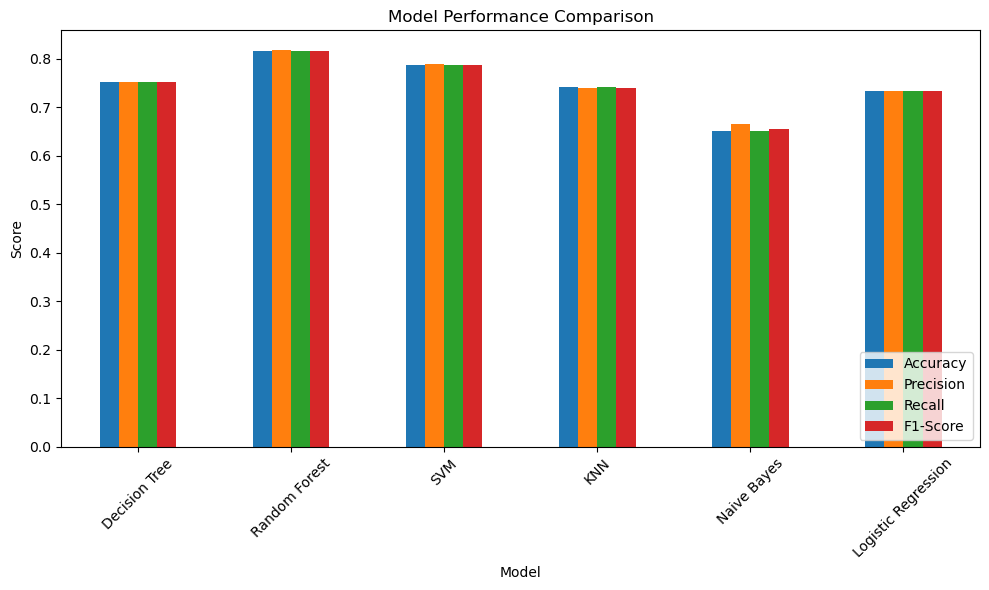

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# 1. Bar Chart for Performance Metrics
results_df.set_index("Model", inplace=True)
results_df.plot(kind="bar", figsize=(10, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

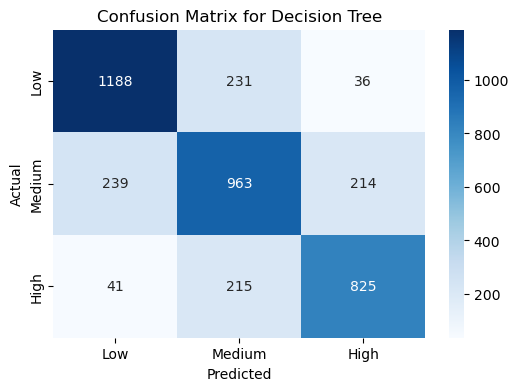

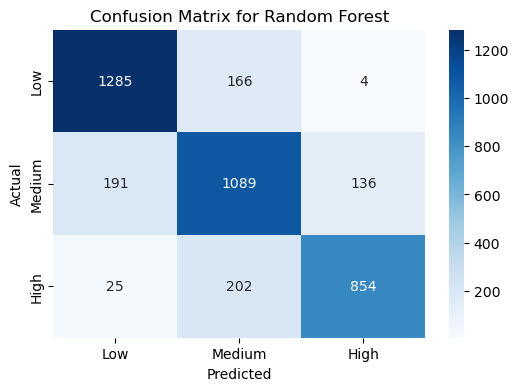

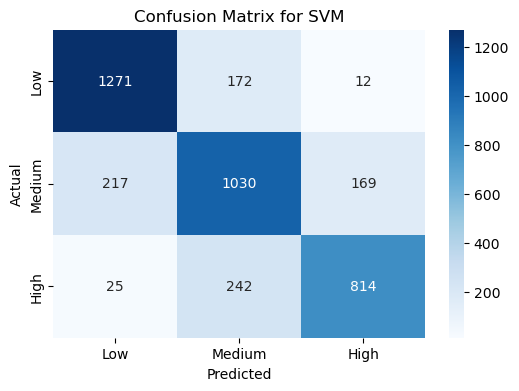

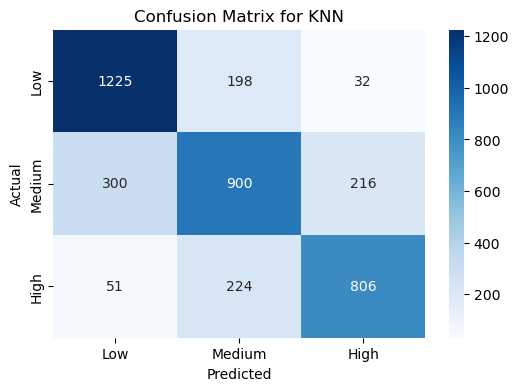

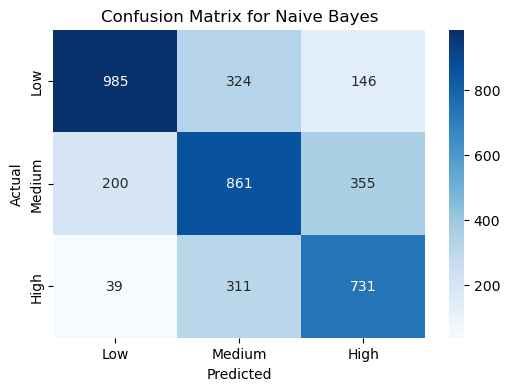

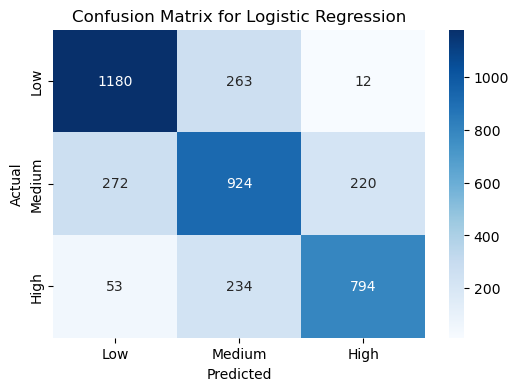

In [13]:

# 2. Confusion Matrix Heatmaps
for model_name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred, labels=y_test.unique())
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=y_test.unique(), yticklabels=y_test.unique())
    plt.title(f"Confusion Matrix for {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


* Clearer Class Separations: The diagonal elements are more dominant, indicating better classification accuracy for each class.
    * "Low" category has 1188 correctly classified instances.
    * "High" category shows improved correct predictions (825 correctly classified instances).

* Reduced Overlap: Misclassifications between adjacent classes (e.g., "Low" being classified as "Medium" and vice versa) have been reduced compared to the earlier matrix.

* Balancing Impact: Balancing the dataset seems to have improved the performance of underrepresented classes like "High," which now has more accurate classifications.

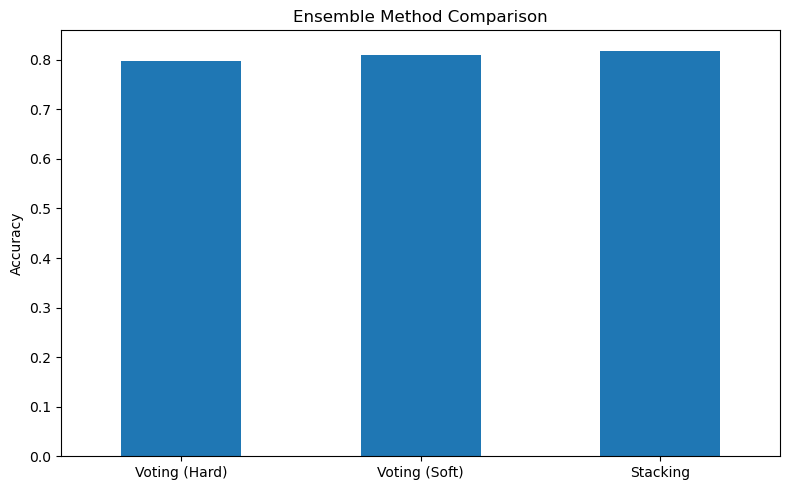

In [14]:

# 3. Ensemble Methods Comparison
ensemble_results = {
    "Voting (Hard)": accuracy_voting_hard,
    "Voting (Soft)": accuracy_voting_soft,
    "Stacking": accuracy_score(y_test, y_pred_stacking)
}
ensemble_df = pd.DataFrame(ensemble_results, index=["Accuracy"]).T
ensemble_df.plot(kind="bar", figsize=(8, 5), legend=False)
plt.title("Ensemble Method Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

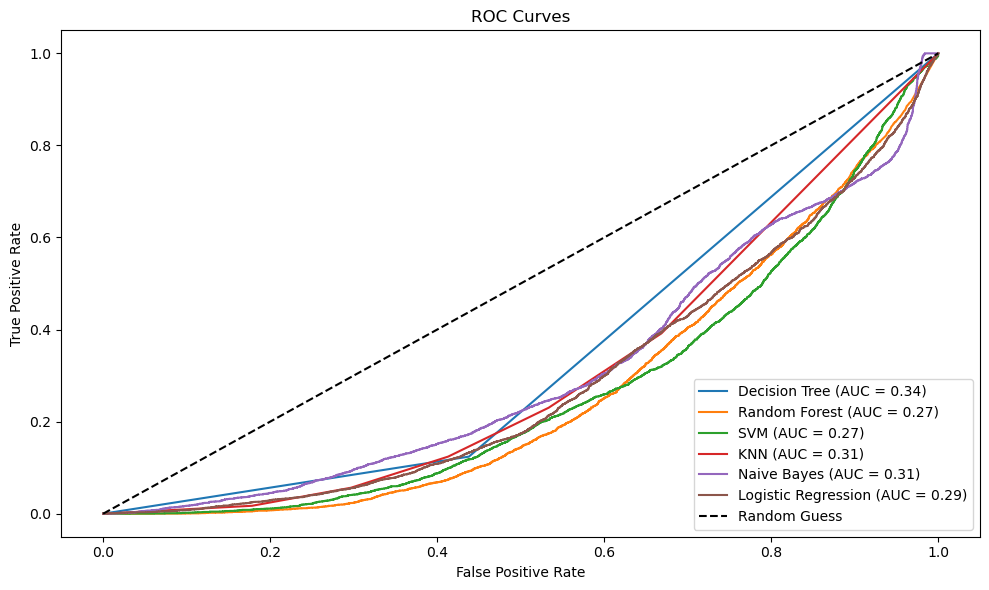

In [15]:




# 4. ROC Curves for Selected Models
plt.figure(figsize=(10, 6))
for model_name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)
        fpr, tpr, _ = roc_curve(pd.get_dummies(y_test).values.ravel(), y_prob.ravel())
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.2f})")
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test_scaled)
        fpr, tpr, _ = roc_curve(pd.get_dummies(y_test).values.ravel(), y_score.ravel())
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


The first chart (more classes) shows lower AUC scores (e.g., Decision Tree: 0.34), meaning models struggle more due to increased complexity and overlapping boundaries between classes.

The second chart (fewer classes) has higher AUC scores (e.g., Decision Tree: 0.48), as reducing the number of classes simplifies the task, improving model performance and class separability.

Fewer classes result in better accuracy but less granularity, while more classes offer detailed predictions but reduced performance.